# AutoML Lab · tabular engine — Classification demo

A fully automated modeling workflow: **drop in a dataset, name the
target, Run All, get a deployable model back** — with the guardrails,
leaderboard discipline, and documentation you'd expect from a commercial
AutoML platform, implemented on scikit-learn.

This notebook is a thin, narrated driver. All logic lives in the importable,
unit-tested [`automl` package](../automl/) one directory up, so the same engine
powers the classification and regression templates without copy-paste drift.


| Stage | What happens |
|---|---|
| `load` | profiling, quality guardrails, date/text feature prep, decision log |
| `split` | locked holdout + CV strategy (random / time-aware / group-aware), metric auto-selection |
| `scan_leakage` | two-detector target-leakage scan |
| `prune_correlation` | pairwise correlation pruning |
| `screen` | every model family cross-validated under identical folds |
| `tune` | Optuna on the finalists, defaults kept as the baseline |
| `rescore` | stacking/voting blenders join; fresh-fold re-score picks the champion |
| `evaluate` | calibration repair, operating point, holdout metrics + bootstrap CIs |
| `explain` | permutation importance, partial dependence, SHAP |
| `export` | model.joblib, metadata.json, predict.py, drift_check.py, Dockerfile, report.html |


**Demo dataset:** [Adult census income](https://archive.ics.uci.edu/dataset/2/adult) (48,842 rows): predict whether income exceeds $50K from census fields. A good stress test — mixed numeric/categorical features, missing values, and a mildly imbalanced target.

**Runtime:** ~20–35 minutes on 4 cores with the settings below. Use `AutoMLConfig.fast(...)` for a first pass in
a couple of minutes.

Every automated decision is printed as it happens and lands in a decision log
that ships with the artifact — automation should never be a black box.

## 0 · Configuration

Everything you should need to touch. The full knob list (guardrail thresholds, leakage thresholds, partitioning, calibration, ensembling...) lives in [`automl/config.py`](../automl/config.py).

In [1]:
import sys
sys.path.insert(0, "..")                    # notebooks/ -> repo folder with automl/

from automl import AutoML, AutoMLConfig

CONFIG = AutoMLConfig(
    # ----- point these at your data, then Run All ---------------------------
    data_path=None,                         # .csv / .parquet; None -> demo dataset below
    target="income",
    task="classification",                  # or "auto" to infer from the target

    # ----- budget (the two knobs that trade accuracy for wall-clock) --------
    optuna_trials=12,                       # per finalist
    optuna_timeout=240,                     # seconds per finalist, whichever first

    artifact_dir="artifacts_classification",
)

aml = AutoML(CONFIG)

/usr/local/lib/python3.11/dist-packages/tqdm/auto.py:21: TqdmWarning: IProgress not found. Please update jupyter and ipywidgets. See https://ipywidgets.readthedocs.io/en/stable/user_install.html
  from .autonotebook import tqdm as notebook_tqdm


## 1 · Load data

With `data_path=None` the notebook pulls the demo dataset. Point `data_path` at your own file (or pass any DataFrame to `aml.load(df)`) and delete this cell's demo branch if you like.

In [2]:
import pandas as pd

if CONFIG.data_path is None:
    ADULT_URL = "https://raw.githubusercontent.com/jbrownlee/Datasets/master/adult-all.csv"
    ADULT_COLUMNS = ["age", "workclass", "fnlwgt", "education", "education_num",
                     "marital_status", "occupation", "relationship", "race", "sex",
                     "capital_gain", "capital_loss", "hours_per_week",
                     "native_country", "income"]
    df = pd.read_csv(ADULT_URL, header=None, names=ADULT_COLUMNS,
                     na_values=["?"], skipinitialspace=True)
else:
    df = None                               # the engine reads CONFIG.data_path itself

df.head() if df is not None else None

,age,workclass,fnlwgt,education,education_num,marital_status,occupation,relationship,race,sex,capital_gain,capital_loss,hours_per_week,native_country,income
0,39,State-gov,77516,Bachelors,13,Never-married,Adm-clerical,Not-in-family,White,Male,2174,0,40,United-States,<=50K
1,50,Self-emp-not-inc,83311,Bachelors,13,Married-civ-spouse,Exec-managerial,Husband,White,Male,0,0,13,United-States,<=50K
2,38,Private,215646,HS-grad,9,Divorced,Handlers-cleaners,Not-in-family,White,Male,0,0,40,United-States,<=50K
3,53,Private,234721,11th,7,Married-civ-spouse,Handlers-cleaners,Husband,Black,Male,0,0,40,United-States,<=50K
4,28,Private,338409,Bachelors,13,Married-civ-spouse,Prof-specialty,Wife,Black,Female,0,0,40,Cuba,<=50K


## 2 · Profile & quality guardrails

Each feature is profiled; features that cannot help (or will hurt) are dropped **with the reason logged**: excessive missingness, constants, ID-like columns. Datetime columns are decomposed into model-ready parts instead of dropped; long free-text columns become TF-IDF features. Duplicate rows are removed so they can't straddle the train/holdout boundary and inflate scores.

In [3]:
aml.load(df)

[ingest] Dropped 52 duplicate rows — duplicates straddling the train/holdout boundary would inflate every score
[quality] Normalized 8 categorical column(s) to string dtype
[quality] 0 feature(s) dropped, 14 remain (0 text)
Rows: 48,790   Features: 14   Task: classification


,dtype,missing_%,n_unique,flags
feature,,,,
age,int64,0.00,74,—
workclass,str,5.73,8,—
fnlwgt,int64,0.00,28523,—
education,str,0.00,16,—
education_num,int64,0.00,16,—
marital_status,str,0.00,7,—
occupation,str,5.75,14,—
relationship,str,0.00,6,—
race,str,0.00,5,—


## 3 · Partition & metric

The holdout is carved off **before** any supervised look at the data and stays locked until the final evaluation. Metric selection then uses the *training partition only*. For temporal or entity-grouped data, set `time_column` / `group_column` in the config — random shuffles silently inflate every score on such data.

LogLoss is the primary metric — it rewards calibrated probabilities, which is what production consumers of a classifier actually need. If the target is imbalanced, class-weighted model variants *compete on the leaderboard* rather than being forced everywhere — weighting distorts exactly the calibration LogLoss protects.

In [4]:
aml.split()

[partition] Train 39,032 rows / holdout 9,758 rows (locked until final evaluation); 5-fold stratified CV
[metric] Primary metric: LogLoss (rewards calibrated probabilities)


## 4 · Target-leakage scan

Two complementary detectors, because each has a blind spot: **|Spearman correlation|** with the target (a shallow tree has a hard R² ceiling and can miss even a literal copy of a continuous target) and a **single-feature depth-6 tree** (catches categorical proxies and non-monotonic leaks). Univariate scans still can't see combinatorial leakage — a second guardrail after modeling flags suspiciously perfect holdout scores.

In [5]:
aml.scan_leakage().head(15)

[leakage] No leakage flags raised


,single_feature_score,abs_spearman_vs_target,leakage_flag
feature,,,
relationship,0.776184,NaN,False
marital_status,0.768112,NaN,False
occupation,0.731066,NaN,False
education,0.717445,NaN,False
education_num,0.717422,NaN,False
age,0.706767,NaN,False
hours_per_week,0.683092,NaN,False
sex,0.622770,NaN,False
capital_gain,0.616695,NaN,False


## 5 · Correlation pruning

For every feature pair above |ρ| = 0.95, the member with the weaker target association is dropped: redundant twins add cost, destabilize linear models, and dilute importance scores.

In [6]:
aml.prune_correlation()

[correlation] No feature pairs above the correlation threshold
[features] Final feature set: 14 features (6 numeric, 8 categorical, 0 high-cardinality categorical, 0 text)


[]

## 6 · Leaderboard, stage 1 — screening

Every family — regularized linear, bagged trees, and four flavors of gradient boosting over three preprocessing blueprints — is cross-validated under identical folds. On large data this runs on a capped sample: cheap elimination first, honest re-scoring later. A model failure is logged and drops that model, never the run.

In [7]:
aml.screen()

[roster] Roster (7 models): ['LogisticRegression', 'RandomForest', 'ExtraTrees', 'HistGradientBoosting', 'XGBoost', 'LightGBM', 'CatBoost']
[leaderboard] Stage-1 screening on a 20,000-row sample of 39,032 train rows (finalists are re-scored on the full partition later, so mixed-basis scores never decide the champion)


  LogisticRegression           LogLoss=0.3218  (1.1s)


  RandomForest                 LogLoss=0.3308  (9.4s)


  ExtraTrees                   LogLoss=0.3816  (10.0s)


  HistGradientBoosting         LogLoss=0.2888  (2.5s)


  XGBoost                      LogLoss=0.2954  (1.5s)


  LightGBM                     LogLoss=0.3023  (1.8s)


  CatBoost                     LogLoss=0.2884  (3.8s)


,model,LogLoss,LogLoss_std,fit_time_s,roc_auc,balanced_accuracy
1,CatBoost,0.288356,0.005356,1.9,0.922598,0.790836
2,HistGradientBoosting,0.288770,0.003570,0.5,0.922425,0.792501
3,XGBoost,0.295374,0.005286,0.6,0.920200,0.789321
4,LightGBM,0.302253,0.005732,0.6,0.919710,0.791309
5,LogisticRegression,0.321754,0.004899,0.5,0.904245,0.767009
6,RandomForest,0.330784,0.017389,4.6,0.902761,0.771348
7,ExtraTrees,0.381624,0.017427,4.7,0.887935,0.761266


## 7 · Stage 2 — tuning with a default-config guarantee

The finalists get an Optuna search (per-family spaces). Two disciplines naive AutoML implementations get wrong and this engine enforces:

1. **The defaults are always a candidate** — scored with the same objective before the search. Tuning can only replace them by beating them, so it can never silently ship a worse model.
2. **Gradient boosting never burns trials on `n_estimators`** — early stopping picks each fold's tree count against a validation split.

In [8]:
tuned = aml.tune()

Finalists advancing to tuning: ['CatBoost', 'HistGradientBoosting', 'XGBoost']


[tuning] CatBoost: tuned beats defaults (0.2795 vs 0.2795, 3/3 trials, 604s)


[tuning] HistGradientBoosting: tuned beats defaults (0.2777 vs 0.2788, 12/12 trials, 63s)


[tuning] XGBoost: defaults kept — no trial beat them (best trial 0.2789 vs default 0.2771, 12/12 trials, 139s)


## 8 · Blenders & the de-biased final leaderboard

Stacking and soft-voting blenders of the finalists join the field — blends of strong, diverse models routinely top AutoML leaderboards. Then every candidate is re-scored with a single CV pass on **fresh folds**: no best-of-N-trials optimism (winner's curse), no comparing sample-based scores against full-data scores. The champion comes from this column only.

In [9]:
aml.rescore()

[tuning] CatBoost: early stopping froze the tree count at 603 (validation-chosen 549, +10% headroom for the full-data fit)


[tuning] XGBoost: early stopping froze the tree count at 240 (validation-chosen 219, +10% headroom for the full-data fit)
[ensemble] Blender candidates join the final re-score: ['Stacked(3)', 'Voting(3)']


  CatBoost                     final LogLoss=0.2778  (8.7s)


  HistGradientBoosting         final LogLoss=0.2775  (7.3s)


  XGBoost                      final LogLoss=0.2771  (1.8s)


  Stacked(3)                   final LogLoss=0.2924  (90.2s)


  Voting(3)                    final LogLoss=0.2751  (17.9s)
[leaderboard] Deployment pick: the leaderboard winner itself — no simpler candidate sits within one standard error of its score
[leaderboard] Champion: Voting(3) (fresh-fold CV LogLoss=0.2751)


,model,screen_LogLoss,final_LogLoss,final_std,source
1,Voting(3),NaN,0.275069,0.0044,blender · fresh-fold CV
2,XGBoost,0.295374,0.277124,0.0044,defaults · fresh-fold CV
3,HistGradientBoosting,0.288770,0.277547,0.0050,tuned · fresh-fold CV
4,CatBoost,0.288356,0.277839,0.0048,tuned · fresh-fold CV
5,Stacked(3),NaN,0.292373,0.0054,blender · fresh-fold CV
6,LightGBM,0.302253,NaN,NaN,stage-1 screen
7,LogisticRegression,0.321754,NaN,NaN,stage-1 screen
8,RandomForest,0.330784,NaN,NaN,stage-1 screen
9,ExtraTrees,0.381624,NaN,NaN,stage-1 screen


## 9 · Final evaluation on the locked holdout

Before touching the holdout, the champion is *finalized* on training data only: calibration is repaired if an out-of-fold check shows it helps, and the decision threshold is tuned on out-of-fold predictions and baked **inside** the artifact (`predict()` applies it — consumers can't accidentally use 0.5). Then one pass over the holdout: metrics, confusion matrix, ROC, lift, calibration curve, and bootstrap confidence intervals so you can tell real differences from noise.

[calibration] Champion already well calibrated (OOF LogLoss 0.2746, isotonic would give 0.2778) -> no calibration wrapper


[threshold] Decision threshold 0.38 maximizes f1 on out-of-fold train predictions; it ships INSIDE the artifact — predict() applies it automatically


Champion: Voting(3)
  holdout LogLoss           : 0.2658
  holdout balanced_accuracy : 0.8355
  holdout ROC_AUC           : 0.9342
  holdout F1                : 0.7362
  holdout precision         : 0.7013
  holdout recall            : 0.7748
  holdout Brier             : 0.0841

              precision    recall  f1-score   support

       <=50K       0.93      0.90      0.91      7422
        >50K       0.70      0.77      0.74      2336

    accuracy                           0.87      9758
   macro avg       0.81      0.84      0.82      9758
weighted avg       0.87      0.87      0.87      9758



,point,ci_2.5%,ci_97.5%,n_resamples
LogLoss,0.2658,0.2564,0.2761,1000.0
balanced_accuracy,0.8355,0.8265,0.8442,1000.0
ROC_AUC,0.9342,0.9290,0.9391,1000.0


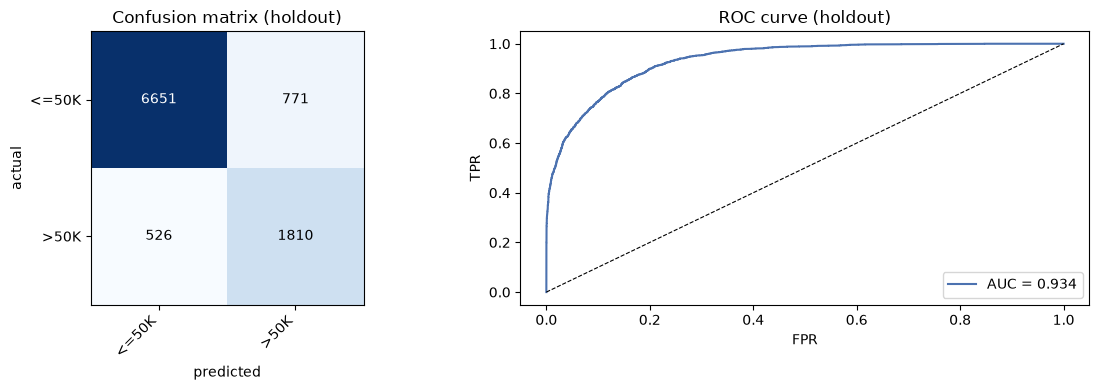

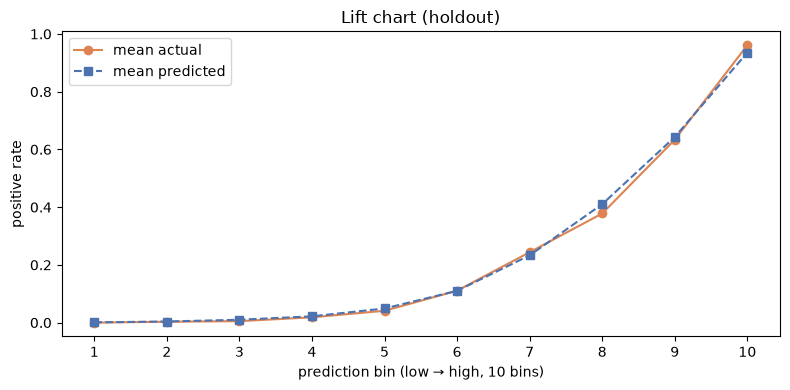

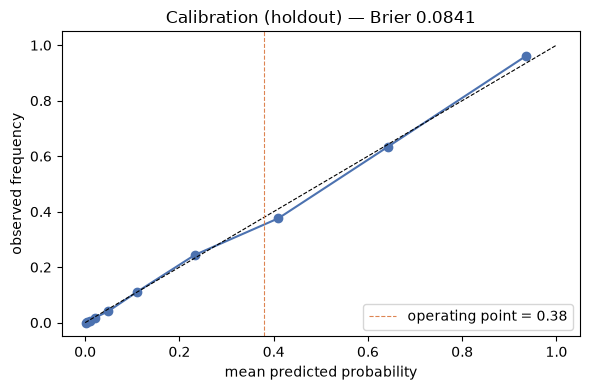

In [10]:
aml.evaluate()
aml.ci

## 10 · Explainability

Permutation importance on the holdout (in original column space), partial dependence for the top numeric features, and SHAP prediction explanations. Caveat stated honestly: permutation importance splits credit between correlated features — read related features as a group.

[explain] SHAP skipped: champion is not a plain pipeline (calibrated ensembles explain poorly)


,feature,importance,std
0,capital_gain,0.153005,0.003640
1,age,0.060980,0.004280
2,relationship,0.044940,0.001126
3,capital_loss,0.032933,0.002135
4,education_num,0.024620,0.001425
5,marital_status,0.024417,0.000874
6,occupation,0.022333,0.001329
7,hours_per_week,0.017485,0.001162
8,workclass,0.003541,0.000395
9,education,0.003097,0.000467


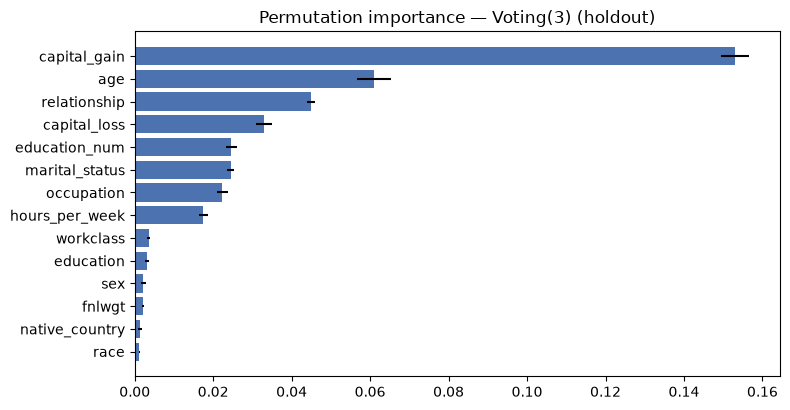

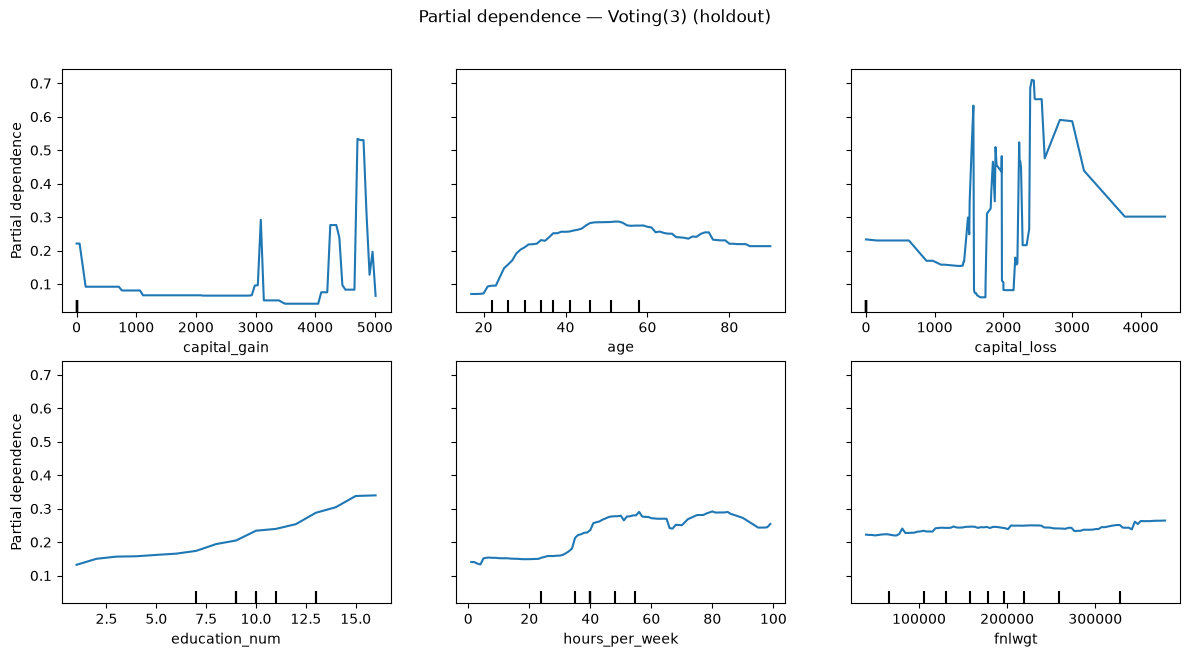

In [11]:
aml.explain().head(15)

## 11 · Using the exported artifact

Everything the artifact needs ships in the artifact folder — no code from this
repo is required at inference time.

**Batch scoring from the command line** (schema checks, recipe application,
probabilities and label decoding included):

```bash
python artifacts_classification/predict.py --input new_rows.csv --output predictions.csv
python artifacts_classification/predict.py --input new_rows.csv --output predictions.csv --drift-report
```

**In any Python process:**

```python
import joblib, pandas as pd

bundle = joblib.load("artifacts_classification/model.joblib")
pipe, le, meta = bundle["pipeline"], bundle["label_encoder"], bundle["metadata"]

new_data = pd.read_csv("new_rows.csv")            # raw rows, original column names
# stateless prep (renames / dates / text-NaN) is recorded in
# meta["preprocessing_recipe"]; predict.py applies it for you — if you score
# manually and used date or text columns, apply it the same way.
predictions = pipe.predict(new_data[meta["features"]])
```

For binary classification the tuned decision threshold lives *inside* the
pipeline (`FixedThresholdClassifier`), so `predict()` already applies the
chosen operating point; `predict_proba()` still returns raw probabilities.

**In Docker** — the folder contains a ready `Dockerfile` and a pinned
`requirements.txt`:

```bash
cd artifacts_classification && docker build -t automl-scorer .
docker run -v $(pwd)/data:/data automl-scorer \
    python predict.py --input /data/new.csv --output /data/preds.csv
```

**Drift monitoring** — `drift_check.py` compares any new batch against the
training distribution (PSI per feature) using only the metadata file.

**Model report** — open `artifacts_classification/report.html` for the shareable summary
(leaderboard, holdout metrics with confidence intervals, all evaluation and
explainability figures, and the full decision audit).

In [12]:
artifact_dir = aml.export()
sorted(p.name for p in artifact_dir.iterdir())

[export] Exported model refit on 100% of rows (48,790); holdout metrics in the metadata describe the pre-refit model, which never saw the holdout


[artifacts] predict.py smoke test passed (scored 20 raw rows through the full recipe + pipeline)
[artifacts] Exported: model.joblib (1.31 MB), metadata.json, predict.py, drift_check.py, Dockerfile, requirements.txt -> artifacts_classification/


[export] Model report -> artifacts_classification/report.html
[export] Total runtime: 18.8 min


['Dockerfile',
 'drift_check.py',
 'metadata.json',
 'model.joblib',
 'predict.py',
 'report.html',
 'requirements.txt']

## 12 · Decision audit

Everything the automation decided on your behalf, in order. This table also ships inside `metadata.json` and `report.html`.

In [13]:
aml.log.to_frame()

,stage,decision
0,ingest,Dropped 52 duplicate rows — duplicates straddl...
1,quality,Normalized 8 categorical column(s) to string d...
2,quality,"0 feature(s) dropped, 14 remain (0 text)"
3,partition,"Train 39,032 rows / holdout 9,758 rows (locked..."
4,metric,Primary metric: LogLoss (rewards calibrated pr...
5,leakage,No leakage flags raised
6,correlation,No feature pairs above the correlation threshold
7,features,"Final feature set: 14 features (6 numeric, 8 c..."
8,roster,"Roster (7 models): ['LogisticRegression', 'Ran..."
9,leaderboard,"Stage-1 screening on a 20,000-row sample of 39..."
